GENERAL FUNCTIONS FOR GF

In [ ]:
def poly_mult_gf2(p1, p2):
    """Multiplies two polynomials in GF(2) using Shift and XOR."""
    # very heavy but with no constraint, we will use it only to calculate g at the beginning
    result = 0
    while p2 > 0:
        if p2 & 1:  
            result ^= p1  # XOR
        p1 <<= 1      # (shift left)
        p2 >>= 1      # (shift right)
        
    return result


def poly_div_gf2(dividend, divisor):
    """Performs polynomial division in GF(2) and returns the remainder."""
    divident_i = dividend
    divisor_len = divisor.bit_length()

    while dividend.bit_length() >= divisor_len:
        shift_amount = dividend.bit_length() - divisor_len
        aligned_divisor = divisor << shift_amount
        dividend ^= aligned_divisor

    if dividend.bit_length() >= divisor_len:
        raise ValueError("Unexpected error: Dividend should be smaller than divisor at this point.")
    else:
        return dividend


def generate_gf_tables(m, prim_poly=None):
    """
    Genera exp_table e log_table per il campo di Galois GF(2^m).
    
    :param m: Esponente del campo (es. 13 per GF(2^13))
    :param prim_poly: (Opzionale) Polinomio primitivo in formato intero. 
                      Se None, cerca nel dizionario interno.
    :return: (exp_table, log_table) come liste di interi.
    """
    
    # Dizionario dei polinomi primitivi standard (includono il bit m-esimo)
    standard_polys = {
        3: 0b1011,     # x^3 + x + 1
        4: 0x13,       # x^4 + x + 1 (usato spesso negli esempi didattici)
        8: 0x11D,      # x^8 + x^4 + x^3 + x^2 + 1 (Standard Reed-Solomon/AES)
        13: 0x201B,    # x^13 + x^4 + x^3 + x + 1 (Il tuo campo per BCH)
        16: 0x1100B    # x^16 + x^12 + x^3 + x + 1
    }
    
    if prim_poly is None:
        if m not in standard_polys:
            raise ValueError(f"Polinomio primitivo per m={m} non predefinito. Inseriscilo manualmente.")
        prim_poly = standard_polys[m]
        
    field_size = 1 << m  # 2^m (es. 8192 per m=13)
    
    # Inizializziamo le liste con zeri
    exp_table = [0] * field_size
    log_table = [0] * field_size
    
    # x rappresenta il valore corrente di alpha^i
    x = 1 
    
    # Iteriamo per tutti gli elementi non nulli del campo (da 0 a 2^m - 2)
    for i in range(field_size - 1):
        exp_table[i] = x
        log_table[x] = i
        
        # Moltiplicare per alpha equivale a fare uno shift a sinistra di 1 bit
        x <<= 1 
        
        # Se lo shift ha acceso il bit m-esimo (overflow rispetto al campo),
        # dobbiamo fare la riduzione modulo il polinomio primitivo (tramite XOR)
        if x & field_size: 
            x ^= prim_poly
            
    # L'elemento alpha^(2^m - 1) è uguale ad alpha^0, ovvero 1. 
    # Chiudiamo il ciclo.
    exp_table[field_size - 1] = 1 
    
    # Nota: log_table[0] matematicamente non è definito. 
    # Lo lasciamo a 0 per comodità, ma non andrebbe mai interrogato.
    
    return exp_table, log_table

exp_table, log_table = generate_gf_tables(m=4)


def gf_mult(a, b):
    if a == 0 or b == 0:
        return 0
    mod_value = len(exp_table) - 1
    index = (log_table[a] + log_table[b]) % mod_value # (o usiamo il modulo a facciamo la LUT doppia)
    return exp_table[index]

def gf_inv(a):
    if a == 0:
        raise ZeroDivisionError("0 non ha inverso in GF")
    mod_value = len(exp_table) - 1
    return exp_table[(mod_value - log_table[a]) % mod_value]





ENCODING FUNCTIONS

In [62]:
def get_g_polynomial(m, t=2):
    """
    Finds the generator polynomial g(x) for a BCH code with error correction capability t in GF(2^m).
    """
    
    min_polys = {
        3: {
            1: 0b1011,      # x^3 + x + 1
            3: 0b1101       # x^3 + x^2 + 1
        },
        4: {
            1: 0b10011,     # x^4 + x + 1
            3: 0b11111      # x^4 + x^3 + x^2 + x + 1
        },
        5: {
            1: 0b100101,    # x^5 + x^2 + 1
            3: 0b111101     # x^5 + x^4 + x^3 + x^2 + 1
        },
        13: {
            1: 0x201B,      # x^13 + x^4 + x^3 + x + 1
            3: 0x26B1       # minimal polynomial for alpha^3 in GF(2^13)
        }
    }

    if m not in min_polys:
        raise ValueError(f"Data for m={m} not available.")

    m1 = min_polys[m][1]
    
    if t == 1:
        return m1
    elif t == 2:
        m3 = min_polys[m][3]
        return poly_mult_gf2(m1, m3)
    else:
        raise ValueError("This function is configured only for t=1 or t=2.")



def encoding(word, g):
    parity_bits = g.bit_length() - 1
    word_s = word << parity_bits
    remainder = poly_div_gf2(word_s, g)
    codeword = word_s ^ remainder
    return codeword

# if __name__ == "__main__":
#     # Il tuo messaggio di 4 bit
#     word = 0b1001 
    
#     # 1. Creiamo il polinomio generatore per t=2
#     g = get_g_polynomial(m=4, t=2)
#     print(f"Polinomio Generatore g(x): {bin(g)}") # Dovrebbe essere 0b1111111 (grado 6)
    
#     # 2. Codifichiamo la parola
#     codeword = encoding(word, g)
#     print(f"Messaggio originale:       {bin(word)}")
#     print(f"Codeword finale:           {bin(codeword)}")


SYNDROMES RESEARCH

In [166]:
# starting with the syndromes calculations, using the Horner method
# the lenght of the LUT strictly depends on m
# for m = 13 P(x) = x^13 + x^4 + x^3 + x + 1 (1010000000001 in binary)

# # EXAMPLE WITH M = 3
# # Ex: alpha^2 = 4. (because  001 -> a^0, 010 -> a^1, 100 -> a^2,  011 -> a^3, 110 -> a^4, 101 -> a^5, 111 -> a^6)
# exp_table = [1, 2, 4, 3, 6, 7, 5,   1, 2, 4, 3, 6, 7, 5] 

# # Ex: alpha^3. log_table[4] = 2.
# # Index 0 is not defined (log of 0 is undefined), so we can set it to 0 or -1 as a placeholder.
# log_table = [0, 0, 1, 3, 2, 6, 4, 5]

def calculate_horner(msg, root_idx):
    root = exp_table[root_idx]
    s_i = 0
    msg_bits = msg.bit_length()
    for bit_pos in range(msg_bits - 1, -1, -1): # most to least significant bit
            # Estraiamo il singolo bit
            bit = (msg >> bit_pos) & 1
            # METODO DI HORNER: Sindrome = (Sindrome_precedente * radice) XOR bit
            s_i = gf_mult(s_i, root) ^ bit
    return s_i

def calculate_syndromes(msg, t):
    """Calculates the syndromes S_1, S_2, ..., S_{2t} for a received message. """
    s1 = calculate_horner(msg, root_idx=1)
    s2 = gf_mult(s1, s1)
    if t == 1:
        return [s1, s2]
    else:
        s3 = calculate_horner(msg, root_idx=3)
        s4 = gf_mult(s2, s2)
        return [s1, s2, s3, s4]

def calculate_syndromes_fast(msg, t=2, m=13):
    """
    Calcola le sindromi S_1...S_{2t} saltando Horner ed evitando gf_mult.
    Utilizza la valutazione polinomiale diretta e l'ottimizzazione delle stringhe C di Python.
    """
    n = (1 << m) - 1  # Per m=13, n = 8191
    
    # bin(msg) in Python è iper-ottimizzato in C.
    # [2:] rimuove il prefisso '0b'
    # [::-1] inverte la stringa in modo che l'indice 0 sia il bit meno significativo (x^0)
    bits = bin(msg)[2:][::-1]
    
    s1 = 0
    s3 = 0
    
    # Valutazione diretta: accumuliamo solo dove i bit sono 1
    for i, bit in enumerate(bits):
        if bit == '1':
            s1 ^= exp_table[i % n]
            if t == 2:
                s3 ^= exp_table[(i * 3) % n]
                
    # Calcoliamo le sindromi pari (radici coniugate) elevando al quadrato.
    # Elevare al quadrato in GF significa raddoppiare il logaritmo!
    
    # S2 = S1^2
    if s1 == 0:
        s2 = 0
    else:
        s2 = exp_table[(log_table[s1] * 2) % n]
        
    if t == 1:
        return [s1, s2]
        
    # S4 = S2^2
    if s2 == 0:
        s4 = 0
    else:
        s4 = exp_table[(log_table[s2] * 2) % n]
        
    return [s1, s2, s3, s4]


DECODING FUNCTIONS -- Berlekamp-Massey

In [1]:


## LOCALIZATOR POLYNOMIAL LAMBDA (using Berlekamp-Massey Algorithm)

def bch_berlekamp_massey(syndromes, t=2):
    """
    syndromes: [S1, S2, S3, S4]
    Returns lambda coefficients
    """
    lambda_poly = [1]        # starting point
    b_poly = [1]             # support polynomial
    L = 0                    # current degree of lambda

    for k in range(1, (2*t) + 1):
        # d: discrepancy
        # d = S_k + sum(Lambda_i * S_{k-i})
        d = syndromes[k-1]
        for i in range(1, L + 1):
            if i < len(lambda_poly): # se è più corto significa che non considera degli zeri in coda
                term = gf_mult(lambda_poly[i], syndromes[k-1-i]) # remember that k-1-i + i = k-1
                d ^= term
        # Shift B(x) = B(x) * x
        b_poly.insert(0, 0) # B(x) must grow with time
        
        if d != 0:
            T = list(lambda_poly)
            
            # check for length and pad with zeros if necessary
            max_len = max(len(lambda_poly), len(b_poly)) 
            lambda_poly += [0] * (max_len - len(lambda_poly)) # pad with zeros if necessary
            
            # 2. update: Lambda(x) = Lambda(x) + d * B(x)
            for i in range(len(b_poly)):
                lambda_poly[i] ^= gf_mult(d, b_poly[i])
            
            if 2 * L < k:
                # 3. update B(x) = Lambda(x) / d
                L = k - L
                d_inv = gf_inv(d)
                b_poly = [gf_mult(val, d_inv) for val in T]
                
    # Pulisce gli zeri in coda e limita a t+1
    lambda_poly += [0] * ((t + 1) - len(lambda_poly))
    return lambda_poly[:t+1]



CHIEN SEARCH

In [165]:
def bch_chien_search(lambda_poly, message_length=4680, m=13):
    """
    lambda_poly: [1, Lambda_1, Lambda_2] (t=2)
    RETRURN: list of error positions (indices)
    """
    error_positions = []
    
    alpha_inv_1 = exp_table[2**m - 2] 
    alpha_inv_2 = exp_table[2**m - 3] 
    
    # Inizializziamo i termini con i coefficienti del polinomio per il bit 0
    term1 = lambda_poly[1]
    term2 = lambda_poly[2]
    
    # Scansioniamo la word bit per bit
    for i in range(message_length):
        
        # 1. Valutazione: Il polinomio si annulla in questa posizione?
        # Stiamo calcolando: 1 ^ term1 ^ term2
        if 1 ^ term1 ^ term2 == 0:
            error_positions.append(i)
            # Se siamo su un microcontrollore
            # message_array[i / 8] ^= (1 << (i % 8)); // Flip del bit!
            
        # 2. Aggiornamento di Chien per il prossimo giro di loop
        term1 = gf_mult(term1, alpha_inv_1)
        term2 = gf_mult(term2, alpha_inv_2)
        
    return error_positions


# optimized for velocity
def bch_chien_search_fast(lambda_poly, message_length=4680, m=13):
    """
    Highly optimized t=2 Chien Search using Log-Domain updates.
    Eliminates all gf_mult function calls in the main loop.
    """
    error_positions = []
    n = (1 << m) - 1  # For m=13, n = 8191
    
    L1 = lambda_poly[1]
    L2 = lambda_poly[2]
    
    # Fast-path: No errors
    if L1 == 0 and L2 == 0:
        return []
        
    # Fast-path: Only 1 error (Lambda_2 is 0)
    # If there's only 1 error, the position is simply the log of Lambda_1
    if L2 == 0:
        pos = log_table[L1]
        if pos < message_length:
            return [pos]
        return []

    # Get the starting logarithmic values
    log_t1 = log_table[L1]
    log_t2 = log_table[L2]
    
    # Scan the word bit by bit
    for i in range(message_length):
        
        # 1. Evaluation using the exp_table
        if 1 ^ exp_table[log_t1] ^ exp_table[log_t2] == 0:
            error_positions.append(i)
            
        # 2. Chien Update in the Log Domain
        # Multiplying by alpha^-1 is just subtracting 1 from the log
        # Multiplying by alpha^-2 is just subtracting 2 from the log
        # Python handles negative modulo perfectly: -1 % 8191 = 8190
        log_t1 = (log_t1 - 1) % n
        log_t2 = (log_t2 - 2) % n
        
    return error_positions


CYCLIC REDUNDANCY CHECK (ENCODING)

In [34]:
def CRC_encoding(word):
    "Function to encode a word with CRC by appending n_bytes of parity bits."
    crc_key = 0xBADB17CC
    word_encoded = word << 32 
    word_div = poly_div_gf2(word_encoded, crc_key)
    word_encoded ^= word_div
    return word_encoded

def CRC_check(received_word):
    crc_key = 0xBADB17CC
    remainder = poly_div_gf2(received_word, crc_key)
    return remainder == 0

if __name__ == "__main__":
    # Esempio di utilizzo del CRC
    original_word = 0x12345678
    encoded_word = CRC_encoding(original_word)
    print(f"Original Word: {hex(original_word)}")
    print(f"Encoded Word with CRC: {hex(encoded_word)}")
    
    # Verifica del CRC (dovrebbe essere True)
    is_valid = CRC_check(encoded_word)
    print(f"CRC Check (should be True): {is_valid}")
    
    # Simuliamo un errore
    corrupted_word = encoded_word ^ 0x1  # Flip del bit meno significativo
    print(f"Corrupted Word: {hex(corrupted_word)}")
    
    # Verifica del CRC (dovrebbe essere False)
    is_valid_corrupted = CRC_check(corrupted_word)
    print(f"CRC Check on Corrupted Word (should be False): {is_valid_corrupted}")

Original Word: 0x12345678
Encoded Word with CRC: 0x1234567812e8b5b8
CRC Check (should be True): True
Corrupted Word: 0x1234567812e8b5b9
CRC Check on Corrupted Word (should be False): False


PROVA

In [ ]:
import random



DATA_SIZE = 1
bit_flips = 2
m = 13
exp_table, log_table = generate_gf_tables(m)
original_data = random.getrandbits(DATA_SIZE * 8) 
word_crc = CRC_encoding(original_data)
codeword = encoding(word_crc, get_g_polynomial(m))
# 2. Corrupt
corrupted_codeword = codeword
for _ in range(bit_flips):
    pos = random.randint(0, codeword.bit_length() - 1)
    corrupted_codeword ^= (1 << pos)
# 3. Decode 
s_corr = calculate_syndromes(corrupted_codeword, t=2)
lambda_coeffs = bch_berlekamp_massey(s_corr, t=2)
message_length = corrupted_codeword.bit_length() 
error_positions = bch_chien_search(lambda_coeffs, message_length, m)
corrected_codeword = corrupted_codeword
for pos_calculated in error_positions:
    corrected_codeword ^= (1 << pos_calculated)

if corrected_codeword == codeword: 
    status = "CORRECTED"
else:
    status = "UNCORRECTABLE"

print(status)

print(f"Corrupted word: {hex(corrupted_codeword)}")
print(f"Error positions: {error_positions}")
print(f"Corrected codeword: {hex(corrected_codeword)}")

CORRECTED
Corrupted word: 0x2004ac687924ead5a
Error positions: [16, 23]
Corrected codeword: 0x2004ac68792cfad5a


TESTING COMPARED TO LIBRARIES

In [172]:
import random
import numpy as np
from tqdm import trange

DATA_SIZE = 512 + 69 + 4  # Data packet size (Payload)
c = 1e3

exp_table, log_table = generate_gf_tables(m)
m = 13
results = {}
bit_flips = 0
cycles = trange(5, desc="Simulating runs")
g_pol = get_g_polynomial(m)
for _ in cycles:
    for n in range(int(c) * (bit_flips + 1)):
        original_data = random.getrandbits(DATA_SIZE * 8) 
        word_crc = CRC_encoding(original_data)
        codeword = encoding(word_crc, g_pol)
        # 2. Corrupt
        corrupted_codeword = codeword
        for _ in range(bit_flips):
            pos = random.randint(0, codeword.bit_length() - 1)
            corrupted_codeword ^= (1 << pos)
        # 3. Decode 
        s_corr = calculate_syndromes_fast(corrupted_codeword, t=2)
        lambda_coeffs = bch_berlekamp_massey(s_corr, t=2)
        message_length = corrupted_codeword.bit_length() 
        error_positions = bch_chien_search_fast(lambda_coeffs, message_length, m)
        corrected_codeword = corrupted_codeword
        for pos_calculated in error_positions:
            corrected_codeword ^= (1 << pos_calculated)
        if corrected_codeword == codeword: 
            status = "CORRECTED"
        else:
            status = "UNCORRECTABLE"
        # 4. Storage
        key = (2, bit_flips)
        if key not in results: results[key] = []
        results[key].append(1 if status != "UNCORRECTABLE" else 0)
    bit_flips +=1



# Calculate the mean success rate (%) for each (T, bit_flips) pair
success_rates = {}
for key, outcomes in results.items():
    success_rates[key] = np.mean(outcomes) * 100

T_values = sorted(list(set([k[0] for k in success_rates.keys()])))
bit_flip_values = sorted(list(set([k[1] for k in success_rates.keys()])))



Simulating runs: 100%|██████████| 5/5 [01:04<00:00, 12.80s/it]


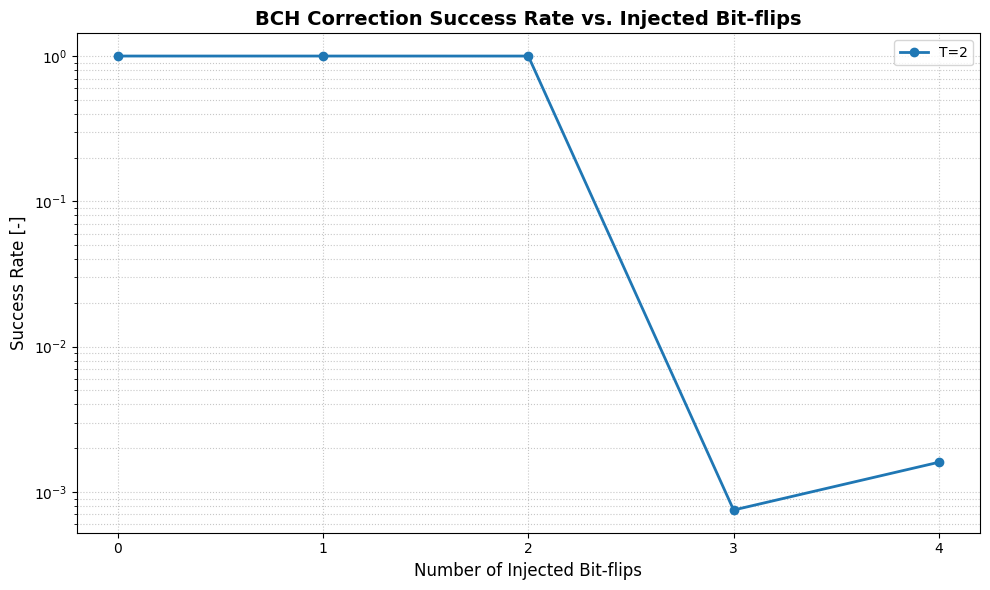

In [170]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for T in T_values:
    # 1. Extract ONLY the data points that exist for this specific T
    t_data = [(k[1], rate/100) for k, rate in success_rates.items() if k[0] == T]
    
    # 2. Sort the data by bit-flips (x-axis) so the line draws cleanly left-to-right
    t_data.sort(key=lambda x: x[0]) 
    
    # 3. Separate into x and y lists
    if t_data:
        x_vals = [item[0] for item in t_data]
        y_vals = [item[1] for item in t_data]
        
        plt.semilogy(x_vals, y_vals, marker='o', linewidth=2, label=f'T={T}')

# plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='50% Threshold')
plt.title('BCH Correction Success Rate vs. Injected Bit-flips', fontsize=14, fontweight='bold')
plt.xlabel('Number of Injected Bit-flips', fontsize=12)
plt.ylabel('Success Rate [-]', fontsize=12)
plt.xticks(bit_flip_values)
plt.grid(True, linestyle=':', alpha=0.7, which='both')
plt.legend()
plt.tight_layout()
plt.show()